# Assignment 3 — CNN Feature Maps, Custom Architecture Design, CIFAR-10 Classification, and Kernel/Activation Analysis

**Course:** CSE4261 – Neural Network and Deep Learning
**Student:** Sania

This notebook covers all five required components:
1. Feature map visualization from a CNN on a personal face image
2. Custom CNN design with architectural justification
3. Implementation and training on CIFAR-10
4. Comparative analysis of three activation functions
5. Critical discussion of six convolutional kernel types (regular, dilated, depthwise-separable, modified depthwise-separable, pointwise, deformable)


In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LeakyReLU, ELU

import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42)

# Work around a TensorFlow Grappler "remapper" graph-optimizer bug that can crash
# training (esp. on GPU) when custom layers with per-tap loops (like our
# DeformableConv2D below) get fused incorrectly. Disabling this one optimizer
# pass has no effect on model correctness, only on graph-level fusion.
tf.config.optimizer.set_experimental_options({'remapper': False})

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Part 1 — Feature Map Visualization on a Personal Face Image

We use **VGG16** (pretrained on ImageNet) as the feature extractor. The original code had two bugs:

1. It fed *all* layers (including the `InputLayer`, which has no meaningful "feature map") into the intermediate model.
2. It did not use VGG16's own `preprocess_input`, so pixel values were not centered/scaled the way VGG16 expects (this changes what the filters respond to).

**Fix:** filter to only `Conv2D`/`MaxPooling2D` layers, and use `preprocess_input` for correct normalization.

Upload your face photo to Colab first (e.g. `sania1.jpeg`) and update the path below.


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


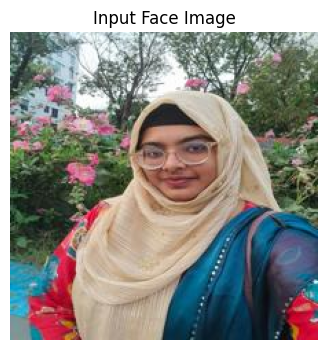

In [2]:
# ---- Load pretrained VGG16 (feature extractor only, no classification head) ----
base_model = VGG16(weights='imagenet', include_top=False)

# ---- Load your face image ----
img_path = "/content/sania1.jpeg"   # <-- update to your uploaded file
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image at {img_path}. Upload your photo to Colab first.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (224, 224))
img_array = np.expand_dims(img_resized.astype('float32'), axis=0)
img_preprocessed = preprocess_input(img_array.copy())   # VGG16-specific normalization

plt.figure(figsize=(4,4))
plt.imshow(img_resized)
plt.title("Input Face Image")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Visualizing layers: ['block1_conv1', 'block1_conv2', 'block1_pool', 'block2_conv1', 'block2_conv2', 'block2_pool']


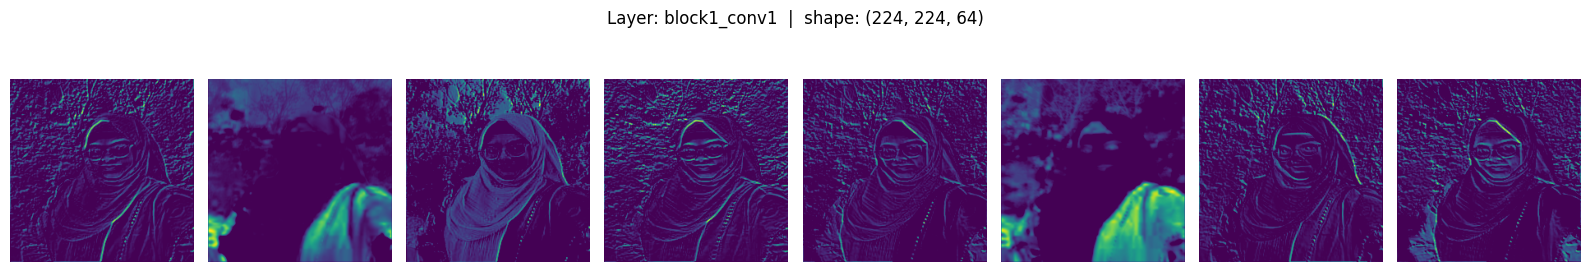

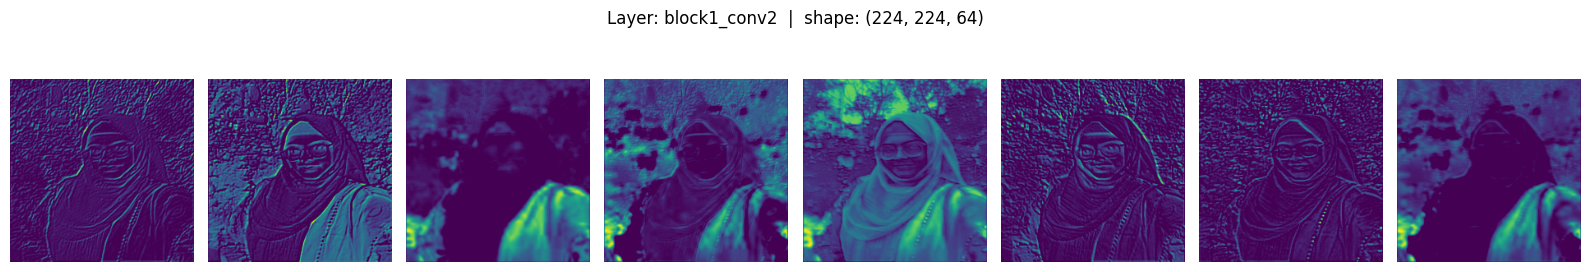

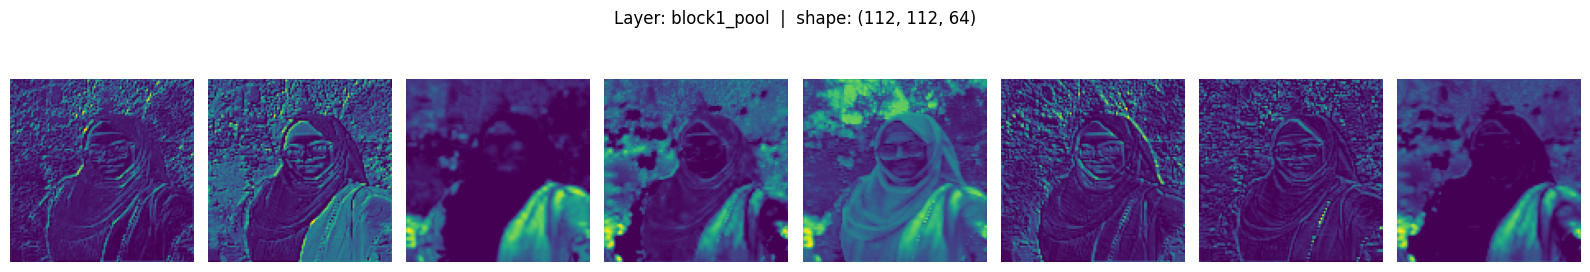

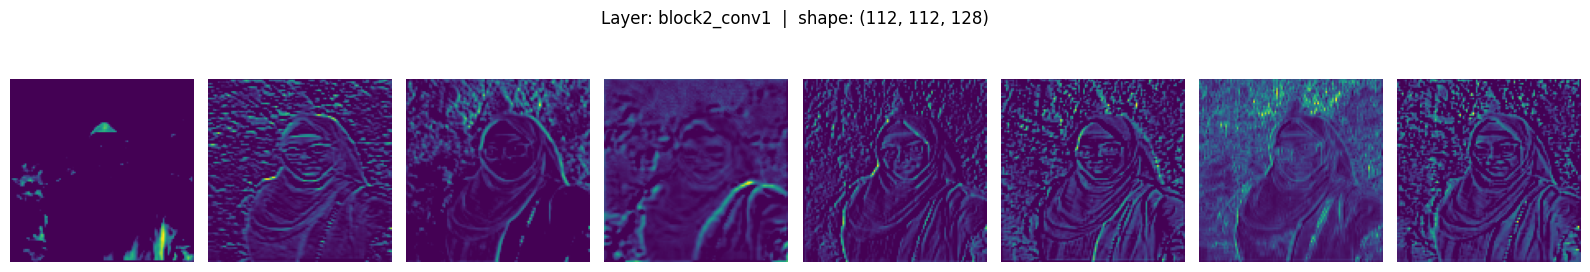

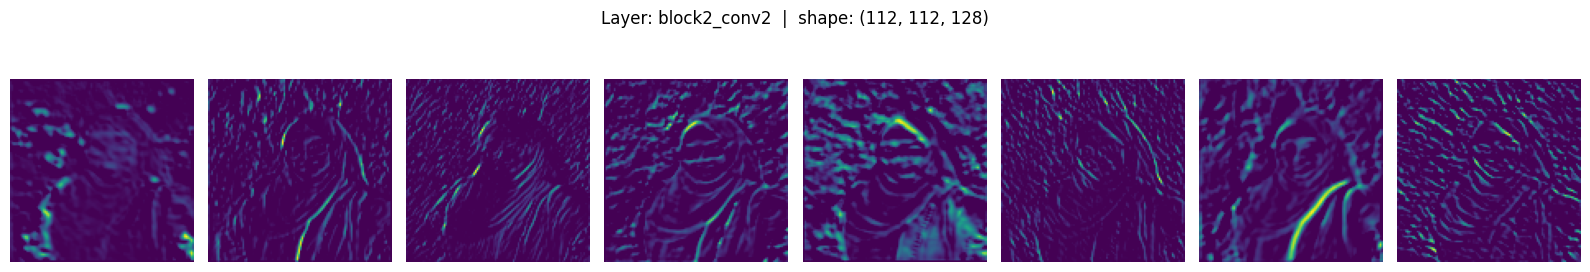

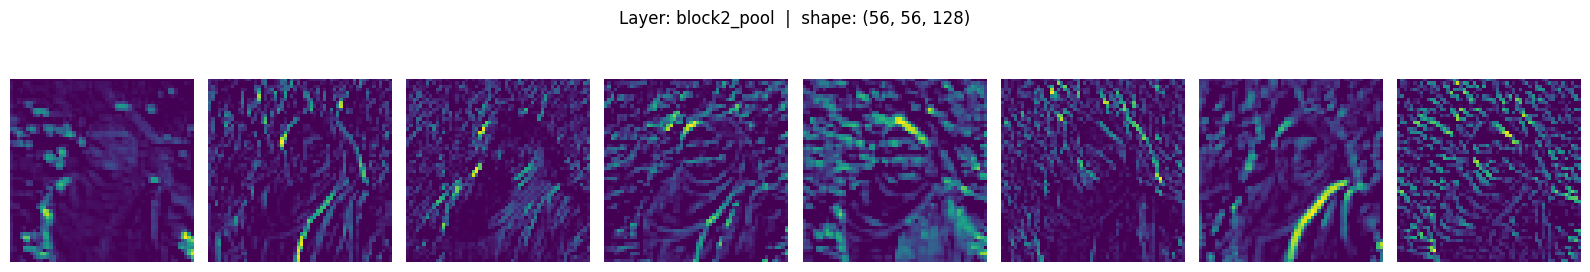

In [3]:
# ---- Select only conv/pooling layers from the first few blocks ----
target_layers = [l for l in base_model.layers if isinstance(l, (layers.Conv2D, layers.MaxPooling2D))][:6]
layer_names = [l.name for l in target_layers]
layer_outputs = [l.output for l in target_layers]

feature_model = Model(inputs=base_model.input, outputs=layer_outputs)
feature_maps = feature_model.predict(img_preprocessed)

print("Visualizing layers:", layer_names)

for name, fmap in zip(layer_names, feature_maps):
    n_channels = min(8, fmap.shape[-1])
    plt.figure(figsize=(16, 3))
    plt.suptitle(f"Layer: {name}  |  shape: {fmap.shape[1:]}")
    for j in range(n_channels):
        plt.subplot(1, n_channels, j + 1)
        plt.imshow(fmap[0, :, :, j], cmap='viridis')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


**What to look for (for the report):**
- **Early layers** (`block1_conv1`, `block1_conv2`): respond to low-level features — edges, color blobs, simple textures. Feature maps should still visually resemble the face's outline.
- **Mid layers** (`block2_*`, `block3_*` if included): respond to combinations of edges — corners, simple shape parts (eyes, nose contours).
- As depth increases, spatial resolution shrinks (due to pooling) and maps become more abstract — less recognizable as a "face" to the human eye, but more semantically meaningful to the network.
- Fill in your own observations per layer here after running, referencing specific channels that activate strongly on eyes/mouth/hair edges.


## Part 2 — Custom CNN Design and Architectural Justification

### Design decisions

| Component | Choice | Justification |
|---|---|---|
| Input | 32×32×3 | Matches CIFAR-10 image size, no resizing needed |
| Conv blocks | 2 blocks, 32 → 64 filters | Progressive channel growth is standard practice: shallow layers learn few generic filters (edges/color), deeper layers need more filters to represent combinations of those features |
| Kernel size | 3×3 | Best accuracy/compute trade-off (standard since VGG); stacking two 3×3 convs approximates a 5×5 receptive field with fewer parameters |
| Padding | `same` | Preserves spatial dimensions before pooling, avoids aggressive shrinkage on a small 32×32 input |
| Pooling | MaxPooling2D(2,2) after each block | Reduces spatial size, builds translation invariance, controls parameter growth in the dense layers |
| Normalization | BatchNormalization (in modified depthwise-separable variant) | Stabilizes/accelerates training, especially useful once the network gets deeper with expansion layers |
| Regularization | Dropout(0.3) before output | CIFAR-10 is small (60k images); dropout reduces overfitting on the fully-connected layers |
| Dense head | Flatten → Dense(128) → Dense(10, softmax) | 128 hidden units are enough capacity for 10-class separation without over-parameterizing given the small conv backbone |
| Kernel/activation type | Configurable (see below) | Lets the same architecture be reused for the Part 4 and Part 5 comparisons without duplicating code |

The architecture is intentionally kept compact (~0.5M parameters) so all six kernel-type variants and three activation variants can be trained within reasonable time on CIFAR-10, while still being deep enough (2 conv blocks + dense head) to demonstrate meaningful differences between kernel types.


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LeakyReLU, ELU

import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42)

# Work around a TensorFlow Grappler "remapper" graph-optimizer bug that can crash
# training (esp. on GPU) when custom layers with per-tap loops (like our
# DeformableConv2D below) get fused incorrectly. Disabling this one optimizer
# pass has no effect on model correctness, only on graph-level fusion.
tf.config.optimizer.set_experimental_options({'remapper': False})

print("TensorFlow version:", tf.__version__)


# ============================================================
# Custom Deformable Conv2D layer (simplified 2D deformable convolution)
# Learns a per-pixel (dx, dy) offset for each of the k*k kernel taps,
# samples the input at those offset locations via bilinear interpolation,
# then applies a learned linear combination (the "convolution" weights).
# This is a simplified/from-scratch implementation of the core idea in
# Dai et al., "Deformable Convolutional Networks" (2017), since Keras/TF
# has no built-in deformable conv layer.
# ============================================================
class DeformableConv2D(layers.Layer):
    def __init__(self, filters, kernel_size=3, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size

    def build(self, input_shape):
        c = input_shape[-1]
        k = self.kernel_size
        # Learns 2 offsets (dx, dy) per kernel tap, per spatial location
        self.offset_conv = layers.Conv2D(2 * k * k, kernel_size=k, padding='same')
        self.kernel_weights = self.add_weight(
            shape=(k * k, c, self.filters), initializer='glorot_uniform',
            trainable=True, name='deform_kernel')
        self.bias = self.add_weight(shape=(self.filters,), initializer='zeros',
                                     trainable=True, name='deform_bias')
        super().build(input_shape)

    def call(self, x):
        k = self.kernel_size
        offsets = self.offset_conv(x)
        B, H, W = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2]

        base_y, base_x = tf.meshgrid(tf.range(H), tf.range(W), indexing='ij')
        base_y = tf.cast(base_y, tf.float32)
        base_x = tf.cast(base_x, tf.float32)

        offsets = tf.reshape(offsets, [B, H, W, k * k, 2])
        sampled_taps = []
        for i in range(k * k):
            dy, dx = offsets[..., i, 0], offsets[..., i, 1]
            ky, kx = i // k - k // 2, i % k - k // 2
            sample_y = base_y[None] + ky + dy
            sample_x = base_x[None] + kx + dx
            sampled_taps.append(self._bilinear_sample(x, sample_x, sample_y))
        stacked = tf.stack(sampled_taps, axis=3)          # (B,H,W,k*k,C)
        out = tf.einsum('bhwkc,kcf->bhwf', stacked, self.kernel_weights)
        return out + self.bias

    def _bilinear_sample(self, x, sx, sy):
        H, W = tf.shape(x)[1], tf.shape(x)[2]
        x0, x1 = tf.floor(sx), tf.floor(sx) + 1
        y0, y1 = tf.floor(sy), tf.floor(sy) + 1
        x0c = tf.clip_by_value(x0, 0, tf.cast(W - 1, tf.float32))
        x1c = tf.clip_by_value(x1, 0, tf.cast(W - 1, tf.float32))
        y0c = tf.clip_by_value(y0, 0, tf.cast(H - 1, tf.float32))
        y1c = tf.clip_by_value(y1, 0, tf.cast(H - 1, tf.float32))

        # Ensure all coordinate values are integers for gathering
        y0_int = tf.cast(y0c, tf.int32)
        x0_int = tf.cast(x0c, tf.int32)
        y1_int = tf.cast(y1c, tf.int32)
        x1_int = tf.cast(x1c, tf.int32)

        # Use tf.concat and tf.expand_dims for index construction to improve Autograph tracing
        idx_Ia = tf.concat([tf.expand_dims(y0_int, axis=-1), tf.expand_dims(x0_int, axis=-1)], axis=-1)
        Ia = tf.gather_nd(x, idx_Ia, batch_dims=1)

        idx_Ib = tf.concat([tf.expand_dims(y1_int, axis=-1), tf.expand_dims(x0_int, axis=-1)], axis=-1)
        Ib = tf.gather_nd(x, idx_Ib, batch_dims=1)

        idx_Ic = tf.concat([tf.expand_dims(y0_int, axis=-1), tf.expand_dims(x1_int, axis=-1)], axis=-1)
        Ic = tf.gather_nd(x, idx_Ic, batch_dims=1)

        idx_Id = tf.concat([tf.expand_dims(y1_int, axis=-1), tf.expand_dims(x1_int, axis=-1)], axis=-1)
        Id = tf.gather_nd(x, idx_Id, batch_dims=1)

        wa = (x1 - sx) * (y1 - sy)
        wb = (x1 - sx) * (sy - y0)
        wc = (sx - x0) * (y1 - sy)
        wd = (sx - x0) * (sy - y0)
        return (wa[..., None]*Ia + wb[..., None]*Ib + wc[..., None]*Ic + wd[..., None]*Id)


def act_layer(activation):
    """Activation factory -- supports the 3 activations compared in Part 4."""
    if activation == 'relu':
        return layers.Activation('relu')
    elif activation == 'leaky_relu':
        return LeakyReLU(negative_slope=0.1)
    elif activation == 'elu':
        return ELU()
    else:
        raise ValueError(f"Unknown activation: {activation}")


def conv_block_layers(filters, kernel_type):
    """Returns the list of layers implementing ONE conv block for the requested kernel type."""
    blk = []
    if kernel_type == 'regular':
        blk.append(layers.Conv2D(filters, 3, padding='same'))
    elif kernel_type == 'dilated':
        blk.append(layers.Conv2D(filters, 3, padding='same', dilation_rate=2))
    elif kernel_type == 'depthwise_separable':
        blk.append(layers.SeparableConv2D(filters, 3, padding='same'))
    elif kernel_type == 'modified_depthwise_separable':
        # MobileNetV2-style inverted residual block:
        # pointwise expansion -> depthwise conv -> pointwise projection
        blk.append(layers.Conv2D(filters * 2, 1, padding='same'))   # pointwise expansion
        blk.append(layers.BatchNormalization())
        blk.append(layers.Activation('relu'))
        blk.append(layers.DepthwiseConv2D(3, padding='same'))       # depthwise
        blk.append(layers.BatchNormalization())
        blk.append(layers.Activation('relu'))
        blk.append(layers.Conv2D(filters, 1, padding='same'))       # pointwise projection
    elif kernel_type == 'pointwise':
        blk.append(layers.Conv2D(filters, 1, padding='same'))
    elif kernel_type == 'deformable':
        blk.append(DeformableConv2D(filters, 3))
    else:
        raise ValueError(f"Unknown kernel_type: {kernel_type}")
    return blk


def build_model(kernel_type='regular', activation='relu', input_shape=(32, 32, 3), num_classes=10):
    """Builds the custom CNN. `kernel_type` and `activation` are swappable
    so the SAME architecture is reused for Part 3 training, Part 4 activation
    comparison, and Part 5 kernel comparison."""
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for filters in [32, 64]:
        for l in conv_block_layers(filters, kernel_type):
            x = l(x)
        x = act_layer(activation)(x)
        x = layers.MaxPooling2D(2, 2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128)(x)
    x = act_layer(activation)(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name=f"CNN_{kernel_type}_{activation}")
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Quick sanity check of the architecture
build_model('regular', 'relu').summary()


TensorFlow version: 2.20.0


Model: "CNN_regular_relu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_26 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_81 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_82 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_83 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

## Part 3 — Implementation and Training on CIFAR-10

Load CIFAR-10, normalize, one-hot encode labels, and train the baseline custom CNN
(`kernel_type='regular'`, `activation='relu'`) to establish a reference performance level
before running the Part 4 and Part 5 comparison sweeps.


In [5]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train:", X_train.shape, "Test:", X_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1489s 9us/step
Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)


In [6]:
baseline_model = build_model(kernel_type='regular', activation='relu')

baseline_history = baseline_model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    verbose=1
)


Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4502 - loss: 1.5182 - val_accuracy: 0.5854 - val_loss: 1.1603
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5889 - loss: 1.1602 - val_accuracy: 0.6532 - val_loss: 0.9904
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6424 - loss: 1.0183 - val_accuracy: 0.6723 - val_loss: 0.9450
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6737 - loss: 0.9287 - val_accuracy: 0.6735 - val_loss: 0.9411
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6981 - loss: 0.8582 - val_accuracy: 0.7024 - val_loss: 0.8683
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7213 - loss: 0.7910 - val_accuracy: 0.7071 - val_loss: 0.8591
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7368 - loss: 0.7398 - val_accuracy: 0.7190 - val_loss: 0.8184
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7551 - loss: 0.6888 - val_accuracy: 

Baseline test accuracy: 0.7035  |  test loss: 1.5046
              precision    recall  f1-score   support

    airplane       0.73      0.76      0.74      1000
  automobile       0.85      0.81      0.83      1000
        bird       0.61      0.55      0.58      1000
         cat       0.51      0.49      0.50      1000
        deer       0.63      0.70      0.66      1000
         dog       0.58      0.62      0.60      1000
        frog       0.81      0.70      0.75      1000
       horse       0.75      0.76      0.75      1000
        ship       0.79      0.84      0.81      1000
       truck       0.79      0.81      0.80      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



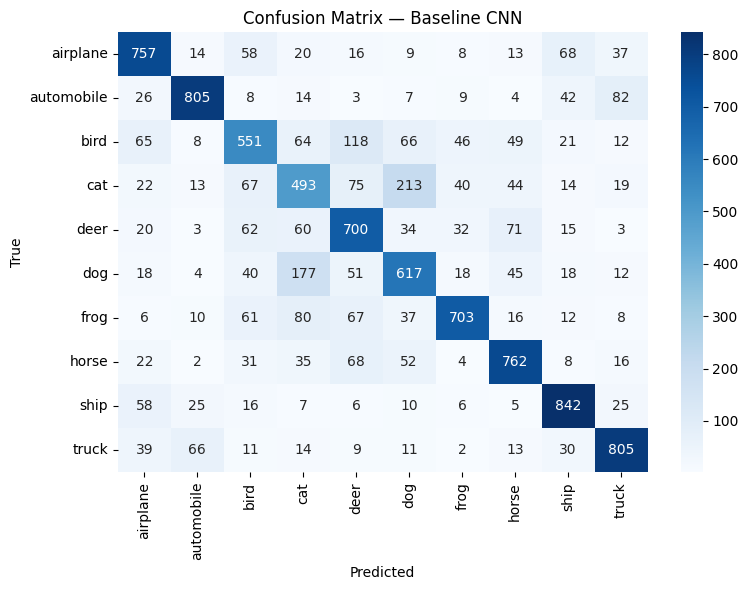

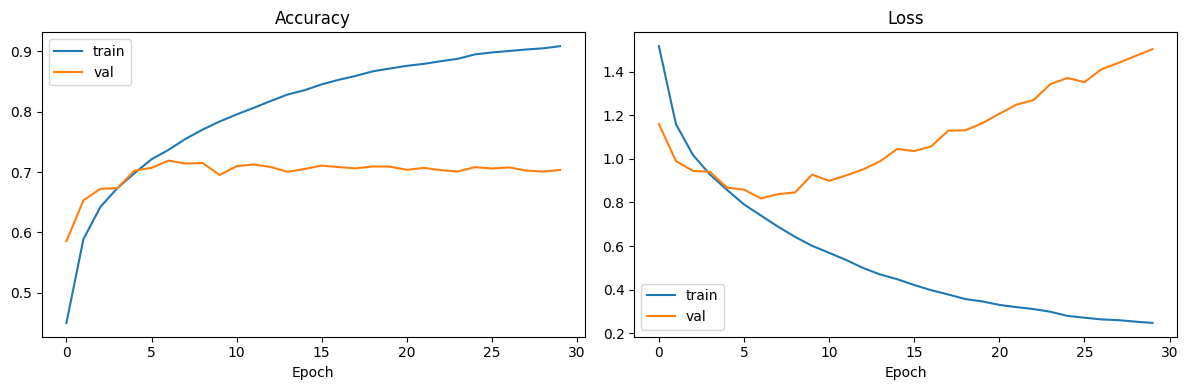

In [7]:
# ---- Evaluation ----
test_loss, test_acc = baseline_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Baseline test accuracy: {test_acc:.4f}  |  test loss: {test_loss:.4f}")

y_pred = np.argmax(baseline_model.predict(X_test, verbose=0), axis=1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred, labels=range(10), target_names=class_names))

cm = confusion_matrix(y_true, y_pred, labels=range(10))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix — Baseline CNN')
plt.tight_layout()
plt.show()

# ---- Training curves ----
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(baseline_history.history['accuracy'], label='train')
axes[0].plot(baseline_history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(baseline_history.history['loss'], label='train')
axes[1].plot(baseline_history.history['val_loss'], label='val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()


## Part 4 — Comparative Analysis of Three Activation Functions

Kernel type is held fixed at `'regular'` so the *only* variable is the activation function:
**ReLU**, **Leaky ReLU** (α = 0.1), and **ELU**.


In [8]:
activations_to_test = ['relu', 'leaky_relu', 'elu']
activation_results = {}
activation_timing = {}

for act in activations_to_test:
    print(f"\nTraining with activation = {act}")
    model = build_model(kernel_type='regular', activation=act)
    t0 = time.time()
    hist = model.fit(X_train, y_train_cat, epochs=10, batch_size=64,
                      validation_data=(X_test, y_test_cat), verbose=1)
    activation_timing[act] = time.time() - t0
    activation_results[act] = hist



Training with activation = relu
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4398 - loss: 1.5480 - val_accuracy: 0.5731 - val_loss: 1.1943
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5717 - loss: 1.2042 - val_accuracy: 0.6400 - val_loss: 1.0372
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6246 - loss: 1.0665 - val_accuracy: 0.6698 - val_loss: 0.9620
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6559 - loss: 0.9785 - val_accuracy: 0.6779 - val_loss: 0.9392
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6799 - loss: 0.9153 - val_accuracy: 0.6926 - val_loss: 0.9049
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6996 - loss: 0.8534 - val_accuracy: 0.6879 - val_loss: 0.9013
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7132 - loss: 0.8096 - val_accuracy: 0.6922 - val_loss: 0.8907
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7275

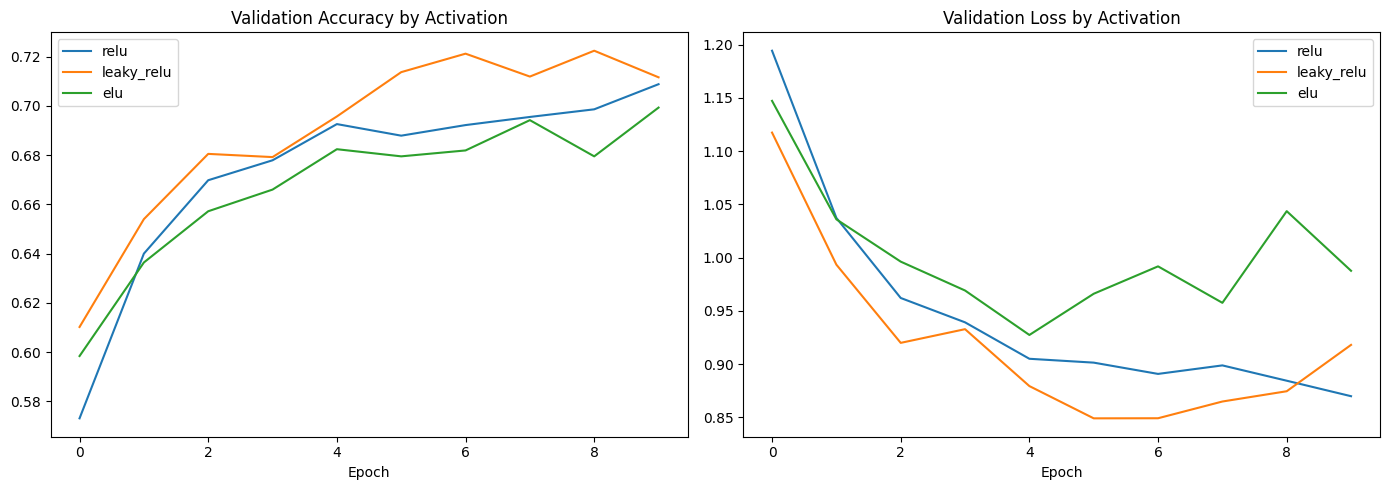

,Activation,Final Val Accuracy,Final Val Loss,Best Val Accuracy,Training Time (s)
0,relu,0.7088,0.869762,0.7088,46.9
1,leaky_relu,0.7116,0.917979,0.7224,47.3
2,elu,0.6993,0.987585,0.6993,48.8


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for act in activations_to_test:
    axes[0].plot(activation_results[act].history['val_accuracy'], label=act)
    axes[1].plot(activation_results[act].history['val_loss'], label=act)
axes[0].set_title('Validation Accuracy by Activation'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Validation Loss by Activation'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

summary_rows = []
for act in activations_to_test:
    h = activation_results[act].history
    summary_rows.append({
        'Activation': act,
        'Final Val Accuracy': h['val_accuracy'][-1],
        'Final Val Loss': h['val_loss'][-1],
        'Best Val Accuracy': max(h['val_accuracy']),
        'Training Time (s)': round(activation_timing[act], 1)
    })
activation_summary_df = pd.DataFrame(summary_rows)
activation_summary_df


**Discussion points to expand in the report (fill in with your actual numbers above):**
- **ReLU**: fast, simple, but can suffer from "dying ReLU" (neurons stuck outputting 0 for negative inputs, gradient permanently 0 there).
- **Leaky ReLU**: fixes dying-neuron problem by allowing a small negative slope (0.1×x for x<0), typically similar or slightly better convergence stability than ReLU.
- **ELU**: smooth, negative saturation region pushes mean activations closer to zero (helps gradient flow / faster convergence in theory) but is more computationally expensive (uses `exp()`) — check the `Training Time` column above to confirm this empirically on your run.
- Note which activation reached the *highest validation accuracy* and which had the *smoothest/most stable* loss curve (fewest oscillations).


## Part 5 — Critical Discussion: Convolutional Kernel Types

Activation is held fixed at the best-performing activation found in Part 4 (update `best_activation`
below once you have that result). Six kernel types are compared: **regular**, **dilated**,
**depthwise-separable**, **modified depthwise-separable** (MobileNetV2-style inverted residual),
**pointwise**, and **deformable** (custom simplified implementation defined in Part 2).


In [21]:
best_activation = 'relu'   # <-- set this to whichever activation won in Part 4

kernel_types_to_test = ['regular', 'dilated', 'depthwise_separable',
                         'modified_depthwise_separable', 'pointwise','deformable']

kernel_results = {}
kernel_timing = {}
kernel_param_counts = {}

for kt in kernel_types_to_test:
    print(f"\nTraining with kernel_type = {kt}")
    try:
        model = build_model(kernel_type=kt, activation=best_activation)
        kernel_param_counts[kt] = model.count_params()
        t0 = time.time()
        hist = model.fit(X_train, y_train_cat, epochs=10, batch_size=64,
                          validation_data=(X_test, y_test_cat), verbose=1)
        kernel_timing[kt] = time.time() - t0
        kernel_results[kt] = hist
    except Exception as e:
        # Don't let one kernel type's failure (e.g. a TF graph-optimizer bug on
        # 'deformable') take down the rest of the sweep. Skip it and keep going.
        print(f"  !! kernel_type='{kt}' failed and was skipped: {type(e).__name__}: {e}")
        kernel_param_counts.pop(kt, None)

if len(kernel_results) < len(kernel_types_to_test):
    skipped = [kt for kt in kernel_types_to_test if kt not in kernel_results]
    print(f"\nNote: the following kernel type(s) were skipped due to errors and will be "
          f"excluded from the comparison plots/tables below: {skipped}")



Training with kernel_type = regular
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4441 - loss: 1.5297 - val_accuracy: 0.5547 - val_loss: 1.2484
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5772 - loss: 1.1884 - val_accuracy: 0.6389 - val_loss: 1.0537
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6331 - loss: 1.0432 - val_accuracy: 0.6771 - val_loss: 0.9463
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6650 - loss: 0.9460 - val_accuracy: 0.6779 - val_loss: 0.9252
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6953 - loss: 0.8692 - val_accuracy: 0.6958 - val_loss: 0.8748
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7154 - loss: 0.8092 - val_accuracy: 0.6841 - val_loss: 0.9281
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7363 - loss: 0.7504 - val_accuracy: 0.6983 - val_loss: 0.8877
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.

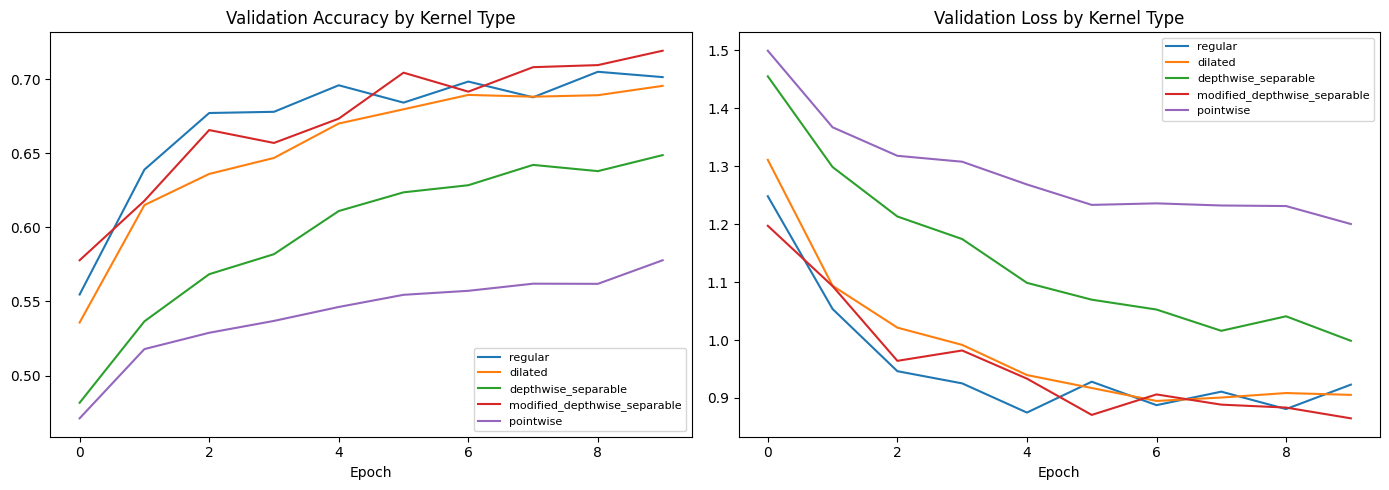

,Kernel Type,Parameters,Final Val Accuracy,Best Val Accuracy,Final Val Loss,Training Time (s)
0,regular,545098,0.7013,0.7049,0.923063,46.5
1,dilated,545098,0.6954,0.6954,0.905402,50.8
2,depthwise_separable,528261,0.6487,0.6487,0.998767,52.4
3,modified_depthwise_separable,543978,0.7191,0.7191,0.864876,91.2
4,pointwise,527946,0.5778,0.5778,1.200382,45.6


In [22]:
successful_kernels = [kt for kt in kernel_types_to_test if kt in kernel_results]

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for kt in successful_kernels:
    axes[0].plot(kernel_results[kt].history['val_accuracy'], label=kt)
    axes[1].plot(kernel_results[kt].history['val_loss'], label=kt)
axes[0].set_title('Validation Accuracy by Kernel Type'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=8)
axes[1].set_title('Validation Loss by Kernel Type'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

kernel_summary_rows = []
for kt in successful_kernels:
    h = kernel_results[kt].history
    kernel_summary_rows.append({
        'Kernel Type': kt,
        'Parameters': kernel_param_counts[kt],
        'Final Val Accuracy': h['val_accuracy'][-1],
        'Best Val Accuracy': max(h['val_accuracy']),
        'Final Val Loss': h['val_loss'][-1],
        'Training Time (s)': round(kernel_timing[kt], 1)
    })
kernel_summary_df = pd.DataFrame(kernel_summary_rows)
kernel_summary_df


### Critical discussion

| Kernel type | How it works | Parameter / compute cost | Typical strength | Typical weakness |
|---|---|---|---|---|
| **Regular** | Dense sliding-window convolution over all input channels | Baseline (highest of the "simple" kernels): `k²·Cin·Cout` | Strong general-purpose feature extraction | No adaptation to object shape/scale; costly at large channel counts |
| **Dilated** | Same kernel, but taps are spread out with gaps (dilation rate) | Same parameter count as regular, larger receptive field for free | Captures wider context without extra params/pooling — good for segmentation-style tasks | Can miss fine local detail (gridding artifacts) if dilation is too aggressive |
| **Depthwise-separable** | Depthwise conv (per-channel spatial filter) + pointwise conv (1×1, mixes channels) | ~`k²·Cin + Cin·Cout` — far fewer params than regular | Big efficiency win (MobileNet-style), good for mobile/edge deployment | Slightly lower representational power per parameter; may need more layers/width to match regular conv accuracy |
| **Modified depthwise-separable** (inverted residual) | Pointwise **expansion** → depthwise → pointwise **projection**, with BatchNorm | More params than plain depthwise-separable but still cheaper than regular at same output width | Expansion gives the depthwise step more channels to work with, improving accuracy while staying efficient (MobileNetV2 insight) | Extra BatchNorm/activation layers add overhead in a very shallow network like this one |
| **Pointwise (1×1)** | Convolution with 1×1 kernel — only mixes channels, no spatial extent | Cheapest: `Cin·Cout`, no spatial term | Efficient channel mixing/dimensionality change | Zero spatial receptive field on its own — cannot learn edges/textures alone, must be combined with spatial kernels |
| **Deformable** | Learns per-location (x,y) offsets so the kernel samples an irregular, input-dependent set of points (via bilinear interpolation) | Extra offset-prediction conv adds parameters/compute vs. regular | Can adapt its receptive field to object shape/pose — useful for irregular or deformed objects | Much more expensive to compute; harder to train stably; offset learning needs enough data/epochs to converge well |

**How to finish this section for the report:** insert the actual `kernel_summary_df` table and validation curves from your run above, then explicitly connect the numbers to the theory — e.g. *"Depthwise-separable had X% fewer parameters than regular but achieved similar/lower accuracy, confirming the efficiency-accuracy trade-off"*, or *"Deformable convolution took the longest per epoch, consistent with its extra offset-prediction and bilinear sampling overhead."*
